# JPEG Algorithm using DCT-II

The JPEG algorithm is a **lossy** compression algorithm that uses the DCT transform coding, where the data encoding is not done on the pixel values themselves, but on a transform.

## Environment Setup

### Library Imports

In [3]:
import os
import numpy as np
from PIL import Image
from IPython.display import display

### Constant Values

In [9]:
IMG_PATH = 'data/512px-Frangipani_flower.jpg'
DCT_BLOCK_SIZE = 8

### Image Preprocessing

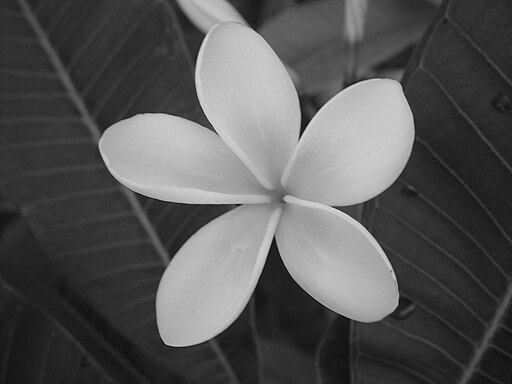

In [11]:
# Open and convert image to grayscale
img_gray = Image.open(IMG_PATH).convert('L')
display(img_gray)

In [17]:
# Convert to Numpy array for processing
img_pixels = np.array(img_gray).astype(np.float32)
print(img_pixels)
print(img_pixels.shape)

[[44. 43. 43. ... 34. 40. 49.]
 [44. 43. 43. ... 34. 36. 42.]
 [44. 43. 43. ... 35. 34. 37.]
 ...
 [26. 28. 30. ... 27. 24. 22.]
 [26. 28. 30. ... 26. 25. 24.]
 [27. 28. 30. ... 25. 25. 24.]]
(384, 512)


## Implementation

### Step 1: Define and Apply the DCT transform to 8x8 Image Blocks

We use the general equation for a 2D image ($N \times M$ image) DCT defined as:

$$
F(u,v) = \left(\frac{2}{N}\right)^{\!1/2}
       \left(\frac{2}{M}\right)^{\!1/2}
       \sum_{i=0}^{N-1}\sum_{j=0}^{M-1}
         \Lambda(i)\,\Lambda(j)\,
         \cos\!\left(\frac{\pi\,u(2i+1)}{2N}\right)
         \cos\!\left(\frac{\pi\,v(2j+1)}{2M}\right)
         f(i,j)
$$

where:

$$
\Lambda(\xi) =
\begin{cases}
\dfrac{1}{\sqrt{2}}, & \text{if } \xi = 0, \\
1, & \text{otherwise}.
\end{cases}
$$

#### Cosine Wave Functions

In the Discrete Cosine Transform, we try to represent an image data as the sum of cosine waves of different frequencies. By adding multiple waves together, we obtain a combination of all of them. As we increase the number of cosine waves, we can increase the number of possible shape of waves that we can produce.
- The new waves are obtained by _weighting_ the input waves and taking their average.
- In JPEG algorithm, we try to remove the higher frequency signals, and ensure that the **essential** pixel information from the image is preserved and can be used to restore a close approximation of the original image.

Each block in the image will be encoded with its own DCT and can be replicated using $8 \times 8 = 64$ cosine wave functions. Thus, any image can be created using 64 wave functions.

In [15]:
def _dct_basis(n=8):
    """
    Return the n x n DCT-II basis matrix or cosine waves C such that for an image block B:
        D = C @ B @ C.T
    Implements normalization consistent with:
        C[u, i] = sqrt(2/n) * alpha(u) * cos(pi * u * (2*i + 1) / (2*n))
    where alpha(0) = 1/sqrt(2), alpha(u>0) = 1.
    """

    u = np.arange(n)[:, None] # shape (n, 1)
    i = np.arange(n)[None, :] # shape (1, n)
    alpha = np.ones((n, 1))
    alpha[0, 0] = 1.0 / np.sqrt(2.0)
    pref = np.sqrt(2.0 / n)
    angles = np.pi * u * (2 * i + 1) / (2.0 * n)
    C = pref * alpha * np.cos(angles)

    return C

The obtained matrix $C$ is the 1D DCT-II basis matrix where each row is a cosine basis function. When you multiply a vector by $C$, you project that vector onto cosine waves. But since an image block $B$ is 2D, we need to apply the DCT to both rows and columns of the image.

The DCT is **separable** and allow us to perform 2D operation on the image block by:
1. Applying 1D DCT along one axis (rows)
2. Applying 1D DCT along the other (columns)

> This **separability trick** reduce the time complexity of performing _full 2D DCT matrix_ operation of $O(n^4)$ to $O(n^3)$. Another advantage of this technique is that it improve cache and memory usage by having the data ready in cache for computation.

Next, we apply the DCT to 8x8 image blocks for a grayscale image.

In [31]:
def dct2_blockwise(img: np.ndarray, block_size: int = 8) -> np.ndarray:
    """
    Compute 2D DCT (block-wise) for a grayscale image.

    Parameters
    ----------
    img: np.ndarray
        2D grayscale image (H x W). dtype can be any numeric type.
    block_size: int
        Block size for DCT (default 8).

    Returns
    -------
    np.ndarray
        DCT coefficients array (float64) with same H x W shape as input.
    """

    if img.ndim != 2:
        raise ValueError("img must be a 2D grayscale array")

    H, W = img.shape
    n = block_size
    C = _dct_basis(n)

    # Pad to multple of block size (use of reflect padding to avoid edge artifacts)
    pad_h = (n - (H % n)) % n  # The last modulo n is added in case H % n = 0
    pad_w = (n - (W % n)) % n

    if pad_h or pad_w:
        img_padded = np.pad(img, ((0, pad_h), (0, pad_w)), mode="reflect")
    else:
        img_padded = img.copy()

    Hp, Wp = img_padded.shape

    # Ensure float for computations
    img_padded = img_padded.astype(np.float64)

    # Output container
    dct_padded = np.zeros_like(img_padded, dtype=np.float64)

    # Process blocks
    for r in range(0, Hp, n):
        for c in range(0, Wp, n):
            block = img_padded[r : r + n, c : c + n]
            # D = C @ block @ C.T
            dct_padded[r : r + n, c : c + n] = C @ block @ C.T

    # Crop to original image size
    dct = dct_padded[:H, :W]
    return dct

Before applying the blockwise DCT operation, we need to center the pixel values around 0 by substracting 128 to each of them to obtain the shifted block because the cosine function varies between 1 and -1 and not 1 and 0.

In [32]:
shifted_block = img_pixels - 128
print(shifted_block)

[[ -84.  -85.  -85. ...  -94.  -88.  -79.]
 [ -84.  -85.  -85. ...  -94.  -92.  -86.]
 [ -84.  -85.  -85. ...  -93.  -94.  -91.]
 ...
 [-102. -100.  -98. ... -101. -104. -106.]
 [-102. -100.  -98. ... -102. -103. -104.]
 [-101. -100.  -98. ... -103. -103. -104.]]


In [33]:
dct_img = dct2_blockwise(shifted_block)
print(dct_img)

[[-6.76000000e+02 -8.50430095e-01  8.79021417e-14 ...  2.98237342e-02
  -5.88589783e-02  5.04572792e-02]
 [-4.64747368e-14 -7.74447249e-15  2.95822839e-30 ...  2.33292306e-01
   2.17086688e-01 -4.85835901e-01]
 [ 8.25868633e-14  3.13784661e-15 -5.76854537e-30 ...  3.75299161e-01
  -1.25000000e-01 -1.96103575e-01]
 ...
 [-7.14784783e-01 -3.51504787e-01 -5.42516992e-01 ... -4.67329614e-01
  -1.43271859e-01  4.26252866e-01]
 [-2.30969883e-01 -6.08829528e-02 -7.32233047e-02 ...  8.35010953e-02
  -3.29319959e-02 -6.93880743e-01]
 [ 4.47279234e-01 -1.76776695e-01 -5.32117698e-01 ...  1.28941266e-01
   4.95695520e-01  1.30649985e-01]]


The top left coefficients for each 8x8 blocks are the **DC** (Direct Current) coefficients, their intensity are larger than the others which are **AC** (Alternative Current) coefficients and they represents that general intensity of the image blocks.

The AC coefficient values at the lower bottom of the DCT matrix are usually smaller than the others and do not contribute too much to the image. That is why, if you take them away, the image will still be identical from a human point of view.

In the JPEG algorithm, we try to take them away to save space in a process called **quantization**.

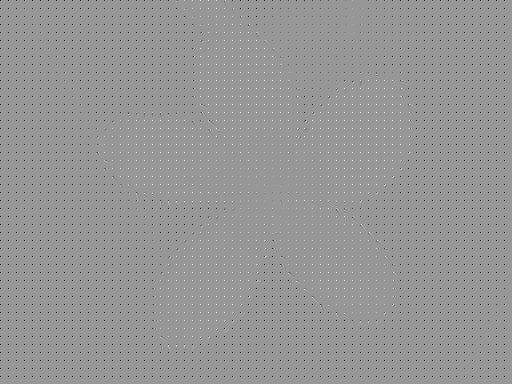

In [26]:
def norm_display_dct(dct_img: np.ndarray) -> np.ndarray:
    """Normalize a DCT output for image display"""

    # Normalize for display
    d_min, d_max = dct_img.min(), dct_img.max()
    dct_disp = 255 * (dct_img - d_min) / (d_max - d_min + 1e-9)

    return dct_disp.astype(np.uint8)


display(Image.fromarray(norm_display_dct(dct_img)))

### Step 2: Quantization

We apply quantization to the image by dividing each 8x8 blocks by the standard JPEG quantization table to remove the contribution of the higher frequency waves and save space.

JPEG has two types of quantization tables:
- One for **luminosity**
- One for **chrominance**
  - This one has a higher penalty on reducing the contribution of the higher frequency data.

We use the one for luminosity here, defined as follows.

In [34]:
Q_TABLE = np.array(
    [
        [16, 11, 10, 16, 24, 40, 51, 61],
        [12, 12, 14, 19, 26, 58, 60, 55],
        [14, 13, 16, 24, 40, 57, 69, 56],
        [14, 17, 22, 29, 51, 87, 80, 62],
        [18, 22, 37, 56, 68, 109, 103, 77],
        [24, 35, 55, 64, 81, 104, 113, 92],
        [49, 64, 78, 87, 103, 121, 120, 101],
        [72, 92, 95, 98, 112, 100, 103, 99],
    ]
)

In [44]:
def quantize_image(dct_image, q_matrix):
    """
    Quantizes a DCT image using a quantization matrix Q.

    Parameters
    ----------
    dct_image: np.ndarray
        The DCT coefficients of size (N, M).
        N and M should be multiple of 8.
    q_matrix: np.ndarray
        The 8x8 quantization matrix.

    Returns
    -------
    np.ndarray: The quantized image.
    """

    h, w = dct_image.shape

    # Ensure the image dimensions are multiples of 8
    if h % 8 != 0 or w % 8 != 0:
        raise ValueError("Image dimensions must be multiples of 8.")

    # 1. Reshape the image ot break it into 8x8 blocks
    # New shape: (rows of blocks, block height, cols of blocks, block width)
    blocks = dct_image.reshape(h // 8, 8, w // 8, 8)

    # 2. Reorder dimensions to group the blocks together for broadcasting
    # New shape: (rows of blocks, cols of blocks, 8, 8)
    blocks = blocks.transpose(0, 2, 1, 3)

    # 3. Perform element-wise division by Q matrix and round to nearest integer.
    # NumPy broadcasts the (8, 8) Q matrix across the first two dimensions.
    quantized_blocks = np.round(blocks / q_matrix)

    # 4. Reshape back to the original image layout.
    # First, move the dimensions back: (rows of blocks, 8, cols of blocks, 8)
    quantized_blocks = quantized_blocks.transpose(0, 2, 1, 3)

    # Finally, collapse into the original (N, M) shape
    quantized_image = quantized_blocks.reshape(h, w)


    return quantized_image
    

[[-42.  -0.   0. ...   0.  -0.   0.]
 [ -0.  -0.   0. ...   0.   0.  -0.]
 [  0.   0.  -0. ...   0.  -0.  -0.]
 ...
 [ -0.  -0.  -0. ...  -0.  -0.   0.]
 [ -0.  -0.  -0. ...   0.  -0.  -0.]
 [  0.  -0.  -0. ...   0.   0.   0.]]


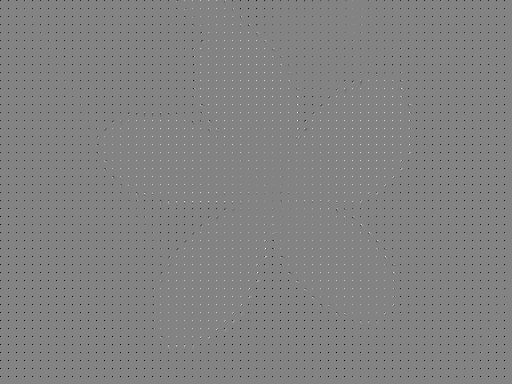

In [47]:
q_img = quantize_image(dct_img, Q_TABLE)
print(q_img)
display(Image.fromarray(norm_display_dct(q_img)))

### Step 3: Serialize Image Information

We list the image pixel values in a 1D arrayt and will use Huffman encoding to further compress the data.
The serialization process is performed in a ZIGZAG fashion.

## References

- [The Discrete Cosine Transform (DCT) - Cardiff University](https://users.cs.cf.ac.uk/Dave.Marshall/Multimedia/node231.html)
- [JPEG DCT, Discrete Cosine Transform (JPEG Pt2)- Computerphile](https://youtu.be/Q2aEzeMDHMA?si=vldyg78mEjpSi3c9)
- [Peak Signal to Noise Ratio (PSNR)](https://www.sciencedirect.com/topics/computer-science/peak-signal-to-noise-ratio)
- [Broadcasting in Python](https://jakevdp.github.io/PythonDataScienceHandbook/02.05-computation-on-arrays-broadcasting.html)